# Analysis: learning curves, bias, statistics

Reads `runs/<config>/seed<k>/metrics.json`, written by `1_implementation.ipynb`, and produces the figures and the statistics table of the report in `report/figures/`. It can be run while the grid is still going: set `PARTIAL = True` to also use unfinished runs.

**Methodology** (notes, section 8):

- Every curve is the mean over seeds with a **95% bootstrap confidence interval**, obtained by resampling the seeds 10,000 times.
- A **final** value is one number per seed: the mean of its last 3 evaluations (steps 90k–100k), which smooths the evaluation noise.
- **Bias metric.** The main metric is the raw bias $\overline{Q - G}$, in reward units. The normalized bias of REDQ, $(Q-G)/|\overline{G}|$, is unusable here: on LunarLander the returns go from negative to positive during learning, so $|\overline{G}|$ passes through 0 and the ratio explodes. It is still shown below as a diagnostic.
- Configurations are compared on these per-seed values with a **Welch t-test** and a **Mann–Whitney U** test. With only 5 seeds per configuration, a non-significant test does not prove that there is no effect.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

RUNS, FIGURES = Path("runs"), Path("report/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
PARTIAL = False   # True: also use unfinished runs
LAST = 3          # evaluations averaged into the "final" value of a seed

# One fixed color per configuration (colorblind-checked order); LayerNorm is also
# shown by the line style / marker, so identity never relies on color alone.
STYLE = {
    "ddpg":    dict(color="#eb6834", ls="-",  marker="o", label="DDPG"),
    "ddpg-ln": dict(color="#eda100", ls="--", marker="s", label="DDPG + LN"),
    "td3":     dict(color="#2a78d6", ls="-",  marker="o", label="TD3"),
    "td3-ln":  dict(color="#1baf7a", ls="--", marker="s", label="TD3 + LN"),
}
plt.rcParams.update({
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8, "legend.fontsize": 7,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#e4e4e0", "grid.linewidth": 0.6, "axes.edgecolor": "#8a8a85",
    "lines.linewidth": 1.6, "pdf.fonttype": 42, "savefig.bbox": "tight", "figure.dpi": 120,
})

## Loading the runs

In [2]:
groups: dict[str, list[dict]] = {}
for path in sorted(RUNS.glob("*/seed*/metrics.json")):
    m = json.loads(path.read_text())
    if (m.get("done") or PARTIAL) and m["evals"]:
        groups.setdefault(m["name"], []).append(m)
NAMES = [n for n in STYLE if n in groups]
for n in NAMES:
    print(f"{n:8s} {len(groups[n])} seeds, {min(len(m['evals']) for m in groups[n])} evaluations")

ddpg     5 seeds, 20 evaluations
ddpg-ln  5 seeds, 20 evaluations
td3      5 seeds, 20 evaluations
td3-ln   5 seeds, 20 evaluations


In [3]:
def curves(name: str, key: str):
    # [n_seeds, T] values of `key`, truncated to the shortest run
    runs = groups[name]
    T = min(len(m["evals"]) for m in runs)
    steps = np.array([e["step"] for e in runs[0]["evals"][:T]])
    return steps, np.array([[e[key] for e in m["evals"][:T]] for m in runs], dtype=float)


def bootstrap_ci(values: np.ndarray, n_boot: int = 10_000, seed: int = 0):
    # mean over axis 0 and its 95% percentile bootstrap CI, resampling rows (= seeds)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    means = values[idx].mean(axis=1)
    return values.mean(axis=0), np.percentile(means, 2.5, axis=0), np.percentile(means, 97.5, axis=0)


def final(name: str, key: str) -> np.ndarray:
    # one value per seed: mean of `key` over its last LAST evaluations
    return np.array([np.mean([e[key] for e in m["evals"][-LAST:]]) for m in groups[name]])


def plot_curves(ax, key: str, ylabel: str, title: str):
    for name in NAMES:
        steps, values = curves(name, key)
        mean, lo, hi = bootstrap_ci(values)
        s = STYLE[name]
        ax.plot(steps / 1000, mean, color=s["color"], ls=s["ls"], label=f"{s['label']} (n={len(values)})")
        ax.fill_between(steps / 1000, lo, hi, color=s["color"], alpha=0.18, linewidth=0)
    ax.set_xlabel("environment steps (×1000)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)

## Figure 1: learning curves

Undiscounted return of the deterministic policy, over 10 evaluation episodes. LunarLander counts as "solved" at 200.

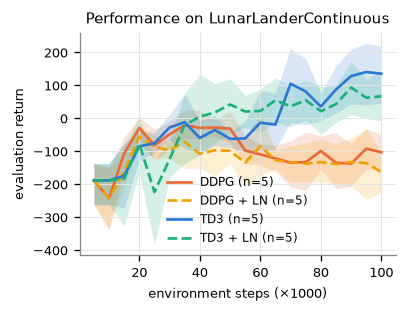

In [4]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
plot_curves(ax, "return_mean", "evaluation return", "Performance on LunarLanderContinuous")
fig.savefig(FIGURES / "returns.pdf")
plt.show()

## Figure 2: overestimation bias along training

Raw bias $\overline{Q_{\phi_1}(s_t,a_t) - G_t}$ on the pairs $(s_t, a_t)$ visited by the deterministic policy, in reward units (discounted, $\gamma = 0.99$). Above 0 means overestimation.

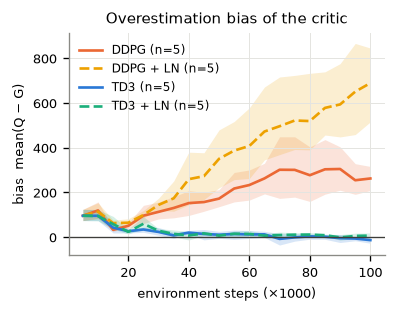

In [5]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
plot_curves(ax, "raw_bias", "bias  mean(Q − G)", "Overestimation bias of the critic")
ax.axhline(0, color="#3d3d3a", linewidth=0.8)
fig.savefig(FIGURES / "bias.pdf")
plt.show()

Diagnostics, not saved for the report. Left: the normalized bias, which explodes whenever $\overline{G}$ crosses 0. Right: mean predicted $Q$ (solid) against mean Monte Carlo return $G$ (dotted).

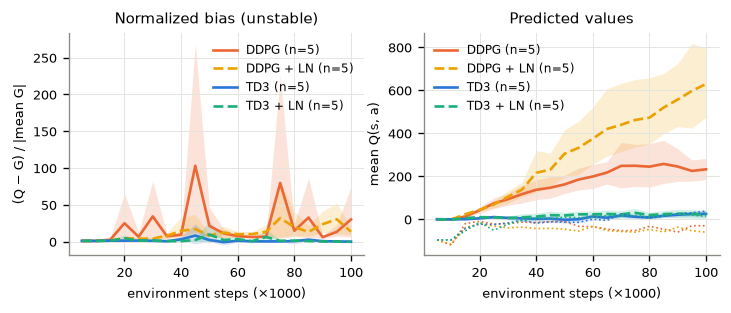

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2.4))
plot_curves(axes[0], "bias_mean", "(Q − G) / |mean G|", "Normalized bias (unstable)")
plot_curves(axes[1], "q_mean", "mean Q(s, a)", "Predicted values")
for name in NAMES:  # dotted: the Monte Carlo returns the Q-values should match
    steps, g = curves(name, "g_mean")
    axes[1].plot(steps / 1000, g.mean(0), color=STYLE[name]["color"], ls=":", linewidth=1)
plt.show()

## Table: final values and tests (Q1)

For each configuration: the mean over seeds of the final return and of the final bias, with a 95% bootstrap CI. Then the 4 comparisons of the 2×2 design: the effect of LN within each algorithm, and DDPG vs. TD3 with and without LN. $\Delta$ is B − A.

In [7]:
rows = []
for name in NAMES:
    r, b = final(name, "return_mean"), final(name, "raw_bias")
    _, r_lo, r_hi = bootstrap_ci(r[:, None]); _, b_lo, b_hi = bootstrap_ci(b[:, None])
    rows.append((name, len(r), r.mean(), r_lo[0], r_hi[0], b.mean(), b_lo[0], b_hi[0]))
    print(f"{STYLE[name]['label']:10s} n={len(r)}  return {r.mean():7.1f} [{r_lo[0]:7.1f}, {r_hi[0]:7.1f}]"
          f"   bias {b.mean():+.1f} [{b_lo[0]:+.1f}, {b_hi[0]:+.1f}]")

PAIRS = [("ddpg", "ddpg-ln"), ("td3", "td3-ln"), ("ddpg", "td3"), ("ddpg-ln", "td3-ln")]
tests = []
print()
for a, b in [p for p in PAIRS if p[0] in groups and p[1] in groups]:
    for key, label in [("return_mean", "return"), ("raw_bias", "bias")]:
        xa, xb = final(a, key), final(b, key)
        p_welch = stats.ttest_ind(xa, xb, equal_var=False).pvalue
        p_mwu = stats.mannwhitneyu(xa, xb, alternative="two-sided").pvalue
        tests.append((a, b, label, xb.mean() - xa.mean(), p_welch, p_mwu))
        print(f"{STYLE[a]['label']:10s} vs {STYLE[b]['label']:10s} {label:6s}  Δ = {xb.mean() - xa.mean():+8.3f}"
              f"   p Welch = {p_welch:.3f}   p MWU = {p_mwu:.3f}")

DDPG       n=5  return  -111.0 [ -159.6,   -63.8]   bias +274.1 [+203.5, +347.1]
DDPG + LN  n=5  return  -144.1 [ -194.0,   -78.8]   bias +644.8 [+466.6, +834.1]
TD3        n=5  return   134.6 [   37.6,   210.6]   bias -7.8 [-18.0, +0.6]
TD3 + LN   n=5  return    74.2 [    2.0,   141.1]   bias +3.9 [-6.5, +15.9]

DDPG       vs DDPG + LN  return  Δ =  -33.104   p Welch = 0.468   p MWU = 0.548
DDPG       vs DDPG + LN  bias    Δ = +370.632   p Welch = 0.016   p MWU = 0.016
TD3        vs TD3 + LN   return  Δ =  -60.398   p Welch = 0.369   p MWU = 0.310
TD3        vs TD3 + LN   bias    Δ =  +11.730   p Welch = 0.202   p MWU = 0.310
DDPG       vs TD3        return  Δ = +245.615   p Welch = 0.004   p MWU = 0.008
DDPG       vs TD3        bias    Δ = -281.953   p Welch = 0.002   p MWU = 0.008
DDPG + LN  vs TD3 + LN   return  Δ = +218.321   p Welch = 0.003   p MWU = 0.016
DDPG + LN  vs TD3 + LN   bias    Δ = -640.855   p Welch = 0.003   p MWU = 0.008


In [8]:
# Same table in LaTeX, included in the report with \input{figures/stats.tex}
L = lambda n: STYLE[n]["label"]
lines = [r"\begin{tabular}{lccc}", r"\toprule",
         r"Configuration & $n$ & Final return [95\% CI] & Final bias [95\% CI] \\", r"\midrule"]
for name, n, r, rlo, rhi, b, blo, bhi in rows:
    lines.append(f"{L(name)} & {n} & {r:.1f} [{rlo:.1f}, {rhi:.1f}] & {b:+.1f} [{blo:+.1f}, {bhi:+.1f}] \\\\")
lines += [r"\midrule", r"Comparison (A vs.\ B) & Metric & $\Delta$ (B $-$ A) & $p$ Welch / MWU \\", r"\midrule"]
for a, b, label, d, pw, pm in tests:
    lines.append(f"{L(a)} vs.\\ {L(b)} & {label} & {d:+.1f} & {pw:.3f} / {pm:.3f} \\\\")
lines += [r"\bottomrule", r"\end{tabular}"]
(FIGURES / "stats.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")
print("\n".join(lines))

\begin{tabular}{lccc}
\toprule
Configuration & $n$ & Final return [95\% CI] & Final bias [95\% CI] \\
\midrule
DDPG & 5 & -111.0 [-159.6, -63.8] & +274.1 [+203.5, +347.1] \\
DDPG + LN & 5 & -144.1 [-194.0, -78.8] & +644.8 [+466.6, +834.1] \\
TD3 & 5 & 134.6 [37.6, 210.6] & -7.8 [-18.0, +0.6] \\
TD3 + LN & 5 & 74.2 [2.0, 141.1] & +3.9 [-6.5, +15.9] \\
\midrule
Comparison (A vs.\ B) & Metric & $\Delta$ (B $-$ A) & $p$ Welch / MWU \\
\midrule
DDPG vs.\ DDPG + LN & return & -33.1 & 0.468 / 0.548 \\
DDPG vs.\ DDPG + LN & bias & +370.6 & 0.016 / 0.016 \\
TD3 vs.\ TD3 + LN & return & -60.4 & 0.369 / 0.310 \\
TD3 vs.\ TD3 + LN & bias & +11.7 & 0.202 / 0.310 \\
DDPG vs.\ TD3 & return & +245.6 & 0.004 / 0.008 \\
DDPG vs.\ TD3 & bias & -282.0 & 0.002 / 0.008 \\
DDPG + LN vs.\ TD3 + LN & return & +218.3 & 0.003 / 0.016 \\
DDPG + LN vs.\ TD3 + LN & bias & -640.9 & 0.003 / 0.008 \\
\bottomrule
\end{tabular}


## Figure 3: bias vs. performance (Q2)

One point per run: its final bias against its final return. The Spearman rank correlation is computed over all runs. It does not assume a linear relation, and it is robust to a run that diverges.

Correlation is not causation: a policy that crashes also changes the scale of $G$. So we also look at the correlation *within* each algorithm.

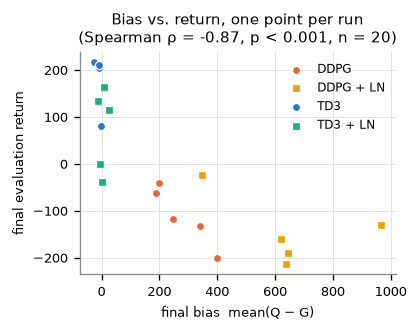

within DDPG: Spearman ρ = -0.61, p = 0.060 (n = 10)
within TD3: Spearman ρ = -0.55, p = 0.098 (n = 10)


In [9]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
xs, ys = [], []
for name in NAMES:
    x, y = final(name, "raw_bias"), final(name, "return_mean")
    s = STYLE[name]
    ax.scatter(x, y, s=24, color=s["color"], marker=s["marker"], edgecolor="white", linewidth=0.8,
               label=s["label"], zorder=3)
    xs += list(x); ys += list(y)
rho, p = stats.spearmanr(xs, ys)
p_txt = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
ax.set_xlabel("final bias  mean(Q − G)")
ax.set_ylabel("final evaluation return")
ax.set_title(f"Bias vs. return, one point per run\n(Spearman ρ = {rho:.2f}, {p_txt}, n = {len(xs)})")
ax.legend(frameon=False, loc="best")
fig.savefig(FIGURES / "bias_vs_return.pdf")
plt.show()

for algo in ["ddpg", "td3"]:
    names = [n for n in NAMES if n.split("-")[0] == algo]
    x = np.concatenate([final(n, "raw_bias") for n in names])
    y = np.concatenate([final(n, "return_mean") for n in names])
    r_, p_ = stats.spearmanr(x, y)
    print(f"within {algo.upper()}: Spearman ρ = {r_:.2f}, p = {p_:.3f} (n = {len(x)})")